Imports:

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# for augmentation
import albumentations as A
import cv2
import os

# for deep-learning model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, GlobalAveragePooling2D, Flatten, BatchNormalization, Dropout, Activation, Input
from tensorflow.keras.regularizers import l2

# for performance evaulation
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

# for saving model
from tensorflow.keras.models import load_model

# for confusion matrix
import numpy as np

#inference
import glob

d:\APN\Classification Model\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Set Random Seeds for Reproducibility

In [2]:
# Set seeds for reproducibility
import random

SEED = 42

# Basic seeds
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# OS-level determinism
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# TF deterministic behavior (GPU-safe)
tf.config.experimental.enable_op_determinism()

print("✓ Full reproducibility enabled (seed=42)")

✓ Full reproducibility enabled (seed=42)


In [3]:
print(tf.__version__)

2.20.0


In [4]:
data_dir = r"D:\APN\Classification Model\20k_dat"         # good and bad images directory
# data_dir = r"D:\APN\Classification Model\data"         # good and bad images directory

GPU VRAM max limit:

In [5]:
flag=False

if flag:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]  #4 GB
        )

1. Visualization of batch of images 

 keras for loading directory, creating batch, image resize, for Visualization

In [6]:
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    batch_size=32,
    image_size=(100,100),
    seed=42
    )

Found 20000 files belonging to 2 classes.


Augmentation

In [7]:
## Augmentation using Albumentations - Apply ONE augmentation type per image

flag = False

if flag:
    # Define different augmentation types (each applied separately)
    augmentation_types = {
        'vflip': A.VerticalFlip(p=1.0),
        'hflip': A.HorizontalFlip(p=1.0),
        'rotate': A.Rotate(limit=90, p=1.0),
        'scale': A.RandomScale(scale_limit=0.3, p=1.0),
        'brightness': A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
    }
    
    # Save augmented copies
    aug_save_dir = os.path.join(data_dir, "augmented")
    os.makedirs(aug_save_dir, exist_ok=True)
    
    # Ensure class folders exist
    class_names = getattr(data, "class_names", ["bad1", "good1"])
    for cname in class_names:
        os.makedirs(os.path.join(aug_save_dir, cname), exist_ok=True)
    
    saved = 0
    
    # Process each batch in the dataset
    for batch_images, batch_labels in data:
        # Process each image in the batch
        for img, label in zip(batch_images, batch_labels):
            label_int = int(label)
            
            # Convert TensorFlow tensor to numpy array (0-255 range)
            img_np = img.numpy().astype(np.uint8)
            
            # Apply EACH augmentation type separately and save each version
            for aug_name, aug_transform in augmentation_types.items():
                # Apply single augmentation
                augmented = aug_transform(image=img_np)
                aug_img = augmented['image']
                
                # Save augmented image with augmentation type in filename
                filename = f"{class_names[label_int]}_{aug_name}_{saved:04d}.jpg"
                out_path = os.path.join(aug_save_dir, class_names[label_int], filename)
                cv2.imwrite(out_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
                saved += 1
    
    print(f"Augmented images saved: {saved}")
    print(f"Output dir: {aug_save_dir}")
    print(f"Augmentation types applied: {list(augmentation_types.keys())}")


2. Data  Normalization

In [8]:
# x - images  (batch,100,100,3) , y - labels  (batch,)
data = data.map(lambda x,y: (x/255.0, y))      # Normalizes the images by scaling pixel values from [0, 255] to [0, 1]. Keeps labels unchanged.
scaled_iterator = data.as_numpy_iterator()     # Converts the normalized dataset to a NumPy iterator and retrieves the first batch.

Visualize the 32 batch images

Images shape: (32, 100, 100, 3)
Labels shape: (32,)
Max pixel value: 1.0
Min pixel value: 0.0


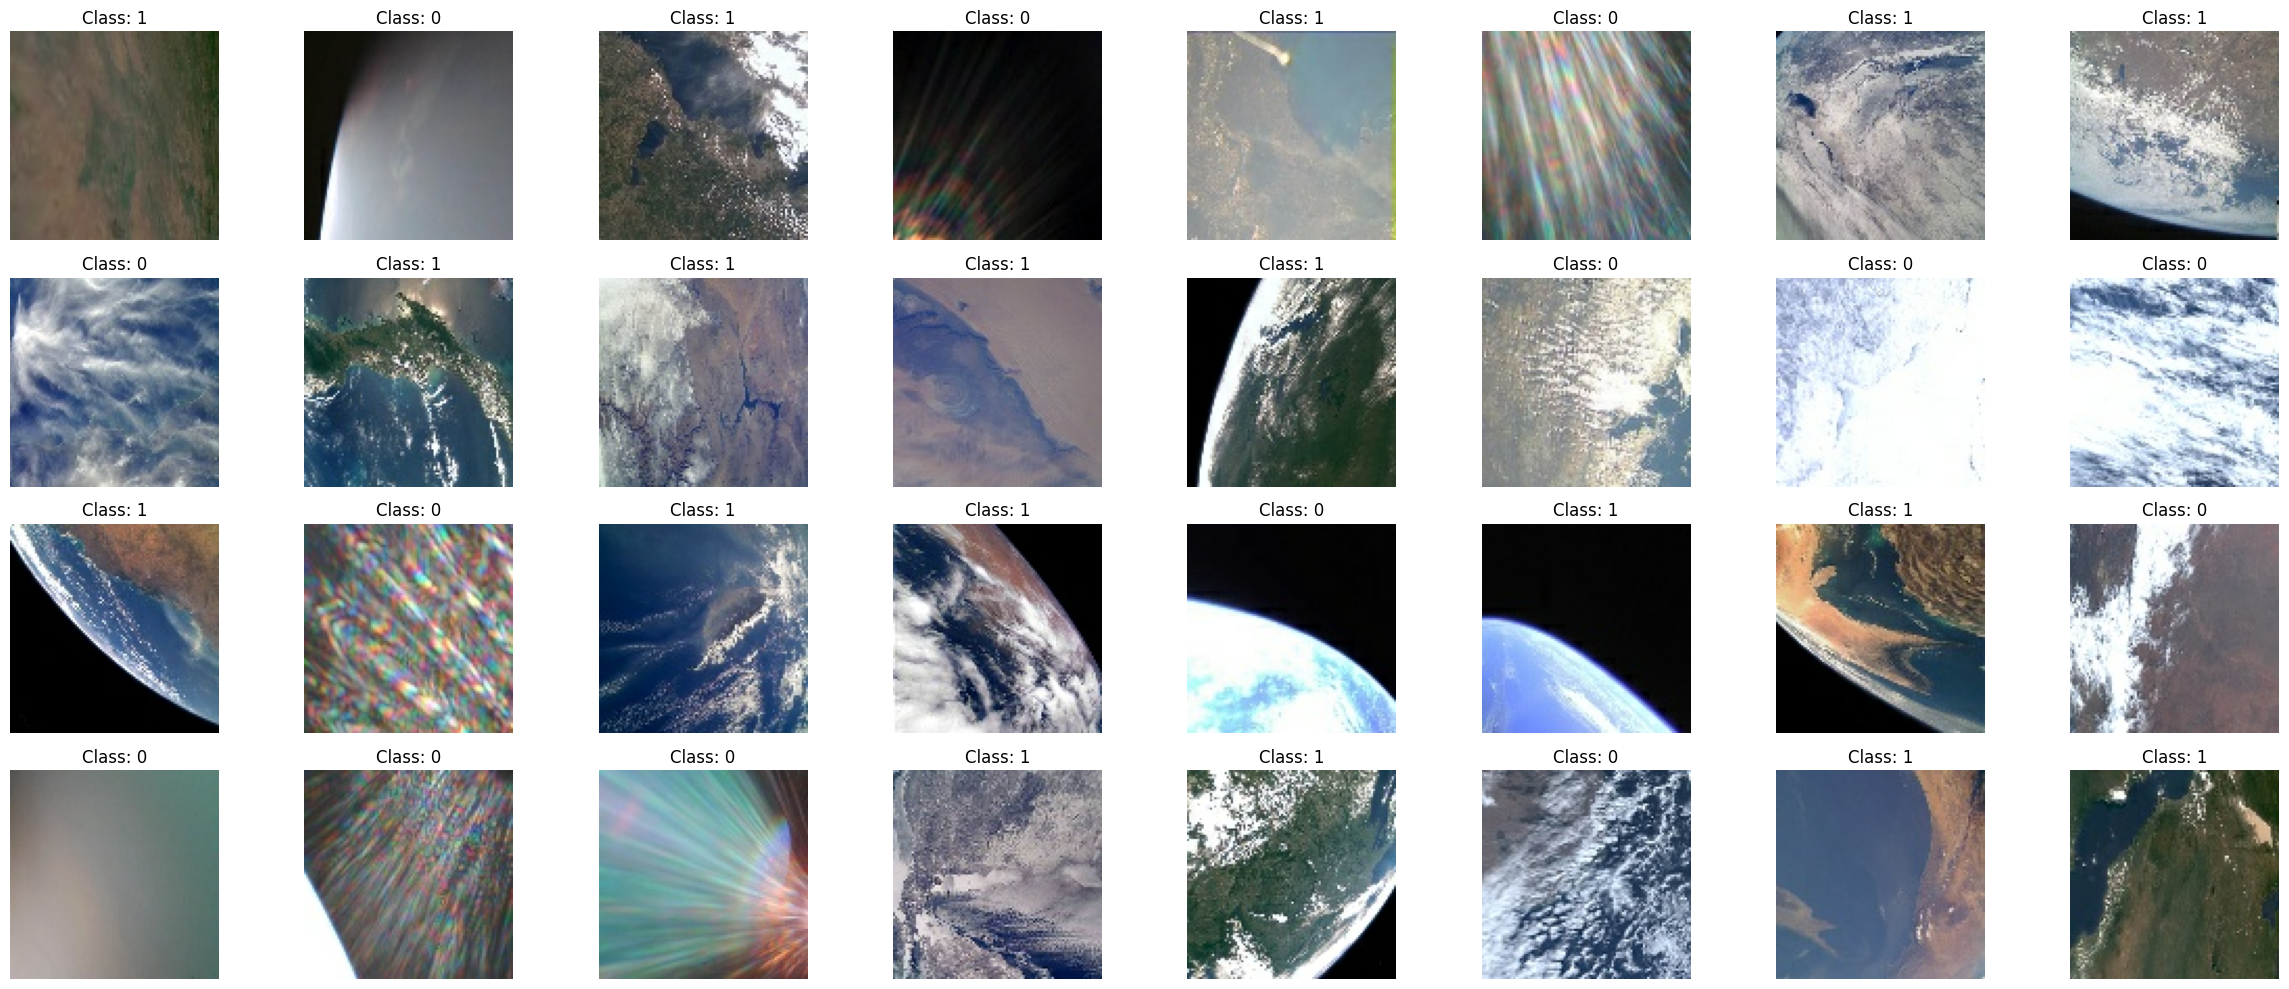

In [9]:
# Convert dataset to NumPy iterator, Libraries like Matplotlib expect NumPy arrays as input.
data_iterator = data.as_numpy_iterator()

# Get the first batch
batch = next(data_iterator)

# batch[0] = images, batch[1] = labels
print("Images shape:", batch[0].shape)          # (batch_size, height, width, channels)
print("Labels shape:", batch[1].shape)          # (batch_size,) which is tuple

print("Max pixel value:", batch[0].max())
print("Min pixel value:", batch[0].min())
# Number of images to display
num_images = 32
nrows = 4
ncols = 8

# Create grid of subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, 10))  

# Flatten axes for easy indexing
axes = axes.flatten()

# Loop through images and display
for idx in range(num_images):                   # takes number from 0 to num_images-1 (ie, 0-15, one by one)
    img = batch[0][idx] 
    label = batch[1][idx]
    axes[idx].imshow(img)                       # Show the image in subplot
    axes[idx].set_title(f"Class: {label}")      # shows label
    axes[idx].axis("off")

# Hide extra subplots (if any)
for idx in range(num_images, nrows*ncols):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()


Visualizing the scaled images.

In [10]:
flag = False

if flag:
    # Convert dataset to NumPy iterator
    scaled_iterator = data.as_numpy_iterator()

    # Get only the first batch
    batch = next(scaled_iterator)                                                                           # Get the first batch
    print(batch[1].shape)
    # Optionally, print min/max values for verification
    print("Max pixel value:", batch[0].max())
    print("Min pixel value:", batch[0].min())

    num_images = 32
    nrows = 4
    ncols = 8


    # Create the grid
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(32, 8))
    axes = axes.flatten()                                                                            # flatten to index easily

    # Plot each image
    for idx in range(num_images):
        img = batch[0][idx]
        label = batch[1][idx]
        axes[idx].imshow(img, vmin=0.0, vmax=1.0)
        axes[idx].set_title(f"Class: {label}")
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()



3. Splitting - 80-10-10 Train-Validation (Test is done separately with external dataset at inference)

In [11]:
print("Number of batches in the dataset:", len(data))  # Number of batches in the dataset

# train_size  ->  type: int  ->  Number of batches to take from the dataset (just a number)
train_size = int(len(data)*.8)                  # 80% of the data for training
val_size = int(len(data)*.1)                 # 10% of the data for validation 
test_size = int(len(data)*.1)              # 10% of the data for testing (for large datasets)

print("Number of Training batch:", train_size,
      "  |  ",
      "Number of Validation batch:", val_size, 
      "   |   "
    "Number of Testing batch:", test_size
      )

# train  ->  type: tf.data.Dataset  ->  The subset of the dataset that contains training batches
train = data.take(train_size)                               # Takes the first 'train_size' batches for training
val = data.skip(train_size).take(val_size)                  # Skips the training batches and takes the next 'val_size' batches for validation
test = data.skip(train_size+val_size).take(test_size)     # Skips the training and validation batches and takes the next 'test_size' batches for testing

print("Training batches:", len(train),
      "  |  ",
      "Validation batches:", len(val),
        "  |  ",
      "Testing batches:", len(test)
)

Number of batches in the dataset: 625
Number of Training batch: 500   |   Number of Validation batch: 62    |   Number of Testing batch: 62
Training batches: 500   |   Validation batches: 62   |   Testing batches: 62


3. Deep Model

In [12]:
# Model (data augmentation now applied to training data before this)
# MaxPool2D(),                # equivalent to : MaxPool2D(pool_size=(2, 2), strides=(2, 2))
# Improvements: Higher dropout, L2 regularization, BatchNormalization
model = Sequential([ 
   
       Input(shape=(100, 100, 3)),

    # -------- Block 1 --------
    Conv2D(
        16, (3,3),
        2,
        padding="same",
        kernel_regularizer=l2(0.001),
    ),
    Activation('relu'),
    Dropout(0.1),

    # -------- Block 2 --------
    Conv2D(
        32, (3,3),
        2,
        padding="same",
        kernel_regularizer=l2(0.001),

    ),
    Activation('relu'),
    Dropout(0.15),

    # -------- Block 3 --------
    Conv2D(
        64, (3,3),
        # 2,
        padding="same",
        kernel_regularizer=l2(0.001)
    ),
    Activation('relu'),
    MaxPool2D(),
    Dropout(0.2),

    # -------- Block 4 --------
    Conv2D(
        128, (3,3),
        # 2,
        padding="same",
        kernel_regularizer=l2(0.001)
    ),
    Activation('relu'),
    MaxPool2D(),
    Dropout(0.25),
    
    # -------- Hidden Layers ---------
    
    # Flatten(),    
    # Dense(512, activation='relu', kernel_regularizer=l2(0.001)),   
    
    GlobalAveragePooling2D(), 
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),   
    
    Dropout(0.45),
    Dense(1, activation='sigmoid'),  # Binary classification output
])

Optimizer and Learning Rate

In [13]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),       
    
    loss='binary_crossentropy',                 
    
    metrics=['accuracy']           
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 50, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,081 (445.63 KB)

 Trainable params: 114,081 (445.63 KB)

 Non-trainable params: 0 (0.00 B)

3. Training data

In [14]:
logdir = 'logs'     # Directory to store TensorBoard logs , src/logs

In [ ]:

# Early Stopping: Stop training when validation loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',                             # track validation loss
    patience=8,                                     # Reduced to prevent overfitting
    restore_best_weights=True,                      # restore model weights from the epoch with the best value of the monitored quantity
    min_delta=0.001                                 # Minimum change to qualify as improvement
)

# # Learning Rate Reduction: Reduce learning rate when validation loss plateaus
# reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.3,                                     # More aggressive - reduce by 70%
#     patience=2,                                     # React faster - wait only 2 epochs
#     min_lr=1e-5,                                    # Don't go below this learning rate
#     verbose=1
# )
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    cooldown=2,
    min_lr=1e-6,
    verbose=1
)

hist = model.fit(
    train,                                          
    validation_data=val,                            
    epochs=50,                                      
    callbacks=[early_stop, reduce_lr]               
)


# 📌 Epoch 1
# val_loss improves → LR stays 0.0005
# 📌 Epoch 2
# val_loss improves → LR stays 0.0005
# 📌 Epoch 3
# val_loss gets worse → no action yet
# 📌 Epoch 4
# val_loss gets worse again → still waiting
# 📌 Epoch 5
# val_loss still not improving → patience reached

# 👉 ReduceLROnPlateau triggers:
# It applies factor 0.5:

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 138ms/step - accuracy: 0.7141 - loss: 0.6185 - val_accuracy: 0.7616 - val_loss: 0.5336 - learning_rate: 0.0010
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 67s 134ms/step - accuracy: 0.7946 - loss: 0.4915 - val_accuracy: 0.8155 - val_loss: 0.4329 - learning_rate: 0.0010
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.8219 - loss: 0.4393 - val_accuracy: 0.8412 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.8350 - loss: 0.4114 - val_accuracy: 0.8407 - val_loss: 0.4149 - learning_rate: 0.0010
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 75s 150ms/step - accuracy: 0.8518 - loss: 0.3831 - val_accuracy: 0.8614 - val_loss: 0.3532 - learning_rate: 0.0010
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 71s 141ms/step - accuracy: 0.8575 - loss: 0.3751 - val_accuracy: 0.8871 - val_loss: 0.3195 - learning_rate: 0.0010
Epoch 7/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.8

Plot performance in graph


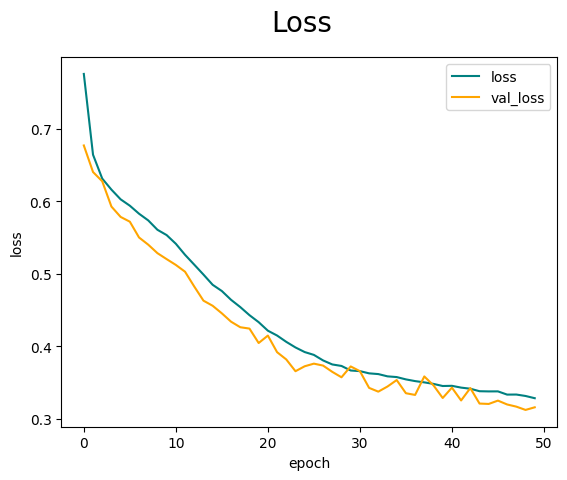

In [ ]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')            
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')  
plt.suptitle('Loss', fontsize=20)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()


Visualize Accuracy

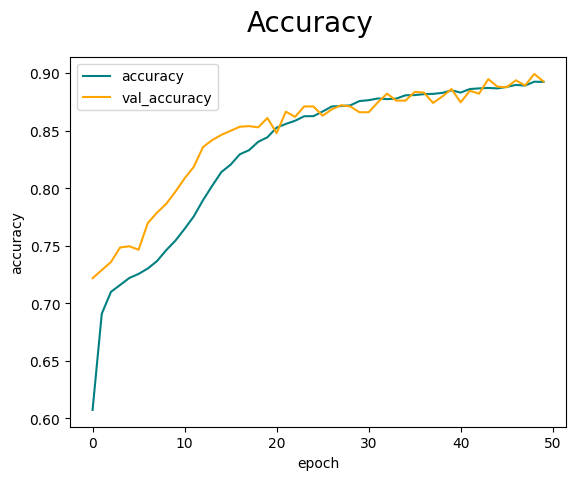

In [ ]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')            
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
plt.suptitle('Accuracy', fontsize=20)
plt.legend(loc='upper left')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.show()

4. Evaluating Performance

In [ ]:
pre = Precision()               # Initializes precision metric
re = Recall()                   # Initializes recall metric
acc = BinaryAccuracy()          # Initializes binary accuracy metric

In [ ]:
len(test)

62

In [ ]:
for batch in test.as_numpy_iterator():
    X, y = batch
    y_pred = model.predict(X)
    # y_pred_labels = tf.cast(y_pred > 0.5, tf.int32)  # Convert probabilities to binary labels (0 or 1)

    pre.update_state(y, y_pred)   # Update precision metric state
    re.update_state(y, y_pred)    # Update recall metric state
    acc.update_state(y, y_pred)   # Update accuracy metric state
    
print(f'Precision: {pre.result().numpy()}, Recall: {re.result().numpy()}, Accuracy: {acc.result().numpy()}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━

Confusion Matrix

training set confusion matrix ( see how well model memorized)

validation set confusion matrix (tune model and detect overfitting)

COMPREHENSIVE CONFUSION MATRICES - TRAINING, VALIDATION & TEST SETS
Found 20000 files belonging to 2 classes.


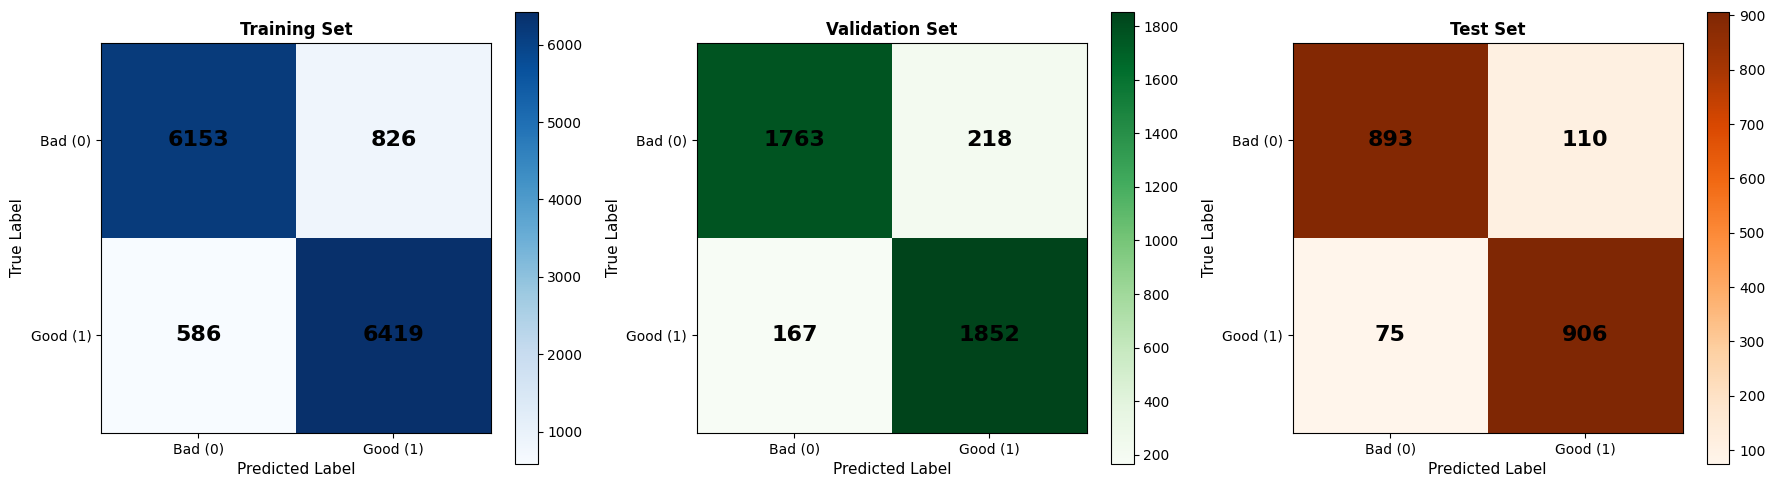


DETAILED CONFUSION MATRIX ANALYSIS

📊 TRAINING SET:
   ✓ True Negatives (TN):  6153 - Correctly predicted as Bad
   ✗ False Positives (FP): 826 - Incorrectly predicted as Good (actually Bad)
   ✗ False Negatives (FN): 586 - Incorrectly predicted as Bad (actually Good)
   ✓ True Positives (TP):  6419 - Correctly predicted as Good
   ────────────────────────────────────────────────────────────────────────────
   Total Predictions:      13984
   Accuracy:                89.90%
   Precision (TP/TP+FP):   0.8860
   Recall (TP/TP+FN):      0.9163
   F1-Score:               0.9009

📊 VALIDATION SET:
   ✓ True Negatives (TN):  1763 - Correctly predicted as Bad
   ✗ False Positives (FP): 218 - Incorrectly predicted as Good (actually Bad)
   ✗ False Negatives (FN): 167 - Incorrectly predicted as Bad (actually Good)
   ✓ True Positives (TP):  1852 - Correctly predicted as Good
   ────────────────────────────────────────────────────────────────────────────
   Total Predictions:      4000
   Accur

In [ ]:
# Collect all predictions from TRAINING, VALIDATION, and TEST sets
print("=" * 80)
print("COMPREHENSIVE CONFUSION MATRICES - TRAINING, VALIDATION & TEST SETS")
print("=" * 80)

# RECREATE DATASETS (since iterators were consumed during training)
data_fresh = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    batch_size=32,
    image_size=(100,100)
)
data_fresh = data_fresh.map(lambda x,y: (x/255.0, y))

# Recreate train/val/test splits
train_size = int(len(data_fresh)*.7)
val_size = int(len(data_fresh)*.2)
test_size = int(len(data_fresh)*.1)

train_fresh = data_fresh.take(train_size)
val_fresh = data_fresh.skip(train_size).take(val_size)
test_fresh = data_fresh.skip(train_size+val_size).take(test_size)

# TRAINING SET
y_true_train = []
y_pred_train = []
for batch in train_fresh.as_numpy_iterator():
    X, y = batch
    y_pred = model.predict(X, verbose=0)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten()
    y_true_train.extend(y)
    y_pred_train.extend(y_pred_labels)

y_true_train = np.array(y_true_train, dtype=int)
y_pred_train = np.array(y_pred_train, dtype=int)

tn_train = np.sum((y_true_train == 0) & (y_pred_train == 0))
fp_train = np.sum((y_true_train == 0) & (y_pred_train == 1))
fn_train = np.sum((y_true_train == 1) & (y_pred_train == 0))
tp_train = np.sum((y_true_train == 1) & (y_pred_train == 1))
cm_train = np.array([[tn_train, fp_train], [fn_train, tp_train]])
acc_train = (tn_train + tp_train) / (tn_train + fp_train + fn_train + tp_train) * 100

# VALIDATION SET
y_true_val = []
y_pred_val = []
for batch in val_fresh.as_numpy_iterator():
    X, y = batch
    y_pred = model.predict(X, verbose=0)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten()
    y_true_val.extend(y)
    y_pred_val.extend(y_pred_labels)

y_true_val = np.array(y_true_val, dtype=int)
y_pred_val = np.array(y_pred_val, dtype=int)

tn_val = np.sum((y_true_val == 0) & (y_pred_val == 0))
fp_val = np.sum((y_true_val == 0) & (y_pred_val == 1))
fn_val = np.sum((y_true_val == 1) & (y_pred_val == 0))
tp_val = np.sum((y_true_val == 1) & (y_pred_val == 1))
cm_val = np.array([[tn_val, fp_val], [fn_val, tp_val]])
acc_val = (tn_val + tp_val) / (tn_val + fp_val + fn_val + tp_val) * 100

# TEST SET
y_true_test = []
y_pred_test = []
for batch in test_fresh.as_numpy_iterator():
    X, y = batch
    y_pred = model.predict(X, verbose=0)
    y_pred_labels = (y_pred > 0.5).astype(int).flatten()
    y_true_test.extend(y)
    y_pred_test.extend(y_pred_labels)

y_true_test = np.array(y_true_test, dtype=int)
y_pred_test = np.array(y_pred_test, dtype=int)

tn_test = np.sum((y_true_test == 0) & (y_pred_test == 0))
fp_test = np.sum((y_true_test == 0) & (y_pred_test == 1))
fn_test = np.sum((y_true_test == 1) & (y_pred_test == 0))
tp_test = np.sum((y_true_test == 1) & (y_pred_test == 1))
cm_test = np.array([[tn_test, fp_test], [fn_test, tp_test]])
acc_test = (tn_test + tp_test) / (tn_test + fp_test + fn_test + tp_test) * 100

# VISUALIZATION - All 3 matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Greens', 'Oranges']
cms = [cm_train, cm_val, cm_test]
titles = ['Training Set', 'Validation Set', 'Test Set']

for idx, (ax, cm, title, cmap) in enumerate(zip(axes, cms, titles, cmaps)):
    im = ax.imshow(cm, cmap=cmap)
    plt.colorbar(im, ax=ax)
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Bad (0)', 'Good (1)'])
    ax.set_yticklabels(['Bad (0)', 'Good (1)'])
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", 
                   color="black", fontsize=16, fontweight='bold')
    
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# PRINT DETAILED METRICS
print("\n" + "=" * 80)
print("DETAILED CONFUSION MATRIX ANALYSIS")
print("=" * 80)

datasets = [
    ("TRAINING SET", tn_train, fp_train, fn_train, tp_train, acc_train),
    ("VALIDATION SET", tn_val, fp_val, fn_val, tp_val, acc_val),
    ("TEST SET", tn_test, fp_test, fn_test, tp_test, acc_test)
]

for dataset_name, tn, fp, fn, tp, accuracy in datasets:
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n📊 {dataset_name}:")
    print(f"   ✓ True Negatives (TN):  {tn:3d} - Correctly predicted as Bad")
    print(f"   ✗ False Positives (FP): {fp:3d} - Incorrectly predicted as Good (actually Bad)")
    print(f"   ✗ False Negatives (FN): {fn:3d} - Incorrectly predicted as Bad (actually Good)")
    print(f"   ✓ True Positives (TP):  {tp:3d} - Correctly predicted as Good")
    print(f"   {'─' * 76}")
    print(f"   Total Predictions:      {tn + fp + fn + tp:3d}")
    print(f"   Accuracy:               {accuracy:6.2f}%")
    print(f"   Precision (TP/TP+FP):   {precision:6.4f}")
    print(f"   Recall (TP/TP+FN):      {recall:6.4f}")
    print(f"   F1-Score:               {f1:6.4f}")
     
print("\n" + "=" * 80)

## Inference - Test on External Dataset

In [ ]:
# Get all test images from both bad and good directories
test_bad_images = glob.glob('../test/bad/*.jpg')
test_good_images = glob.glob('../test/good/*.jpg')
all_test_images = test_bad_images + test_good_images

# Shuffle the images to display them randomly
import random
random.shuffle(all_test_images)

print(f"Found {len(test_bad_images)} bad images and {len(test_good_images)} good images")
print(f"Total test images: {len(all_test_images)}")


# Collect predictions for confusion matrix
y_true_test = []
y_pred_test = []

Found 12 bad images and 32 good images
Total test images: 44


Display the test result with probablity and label

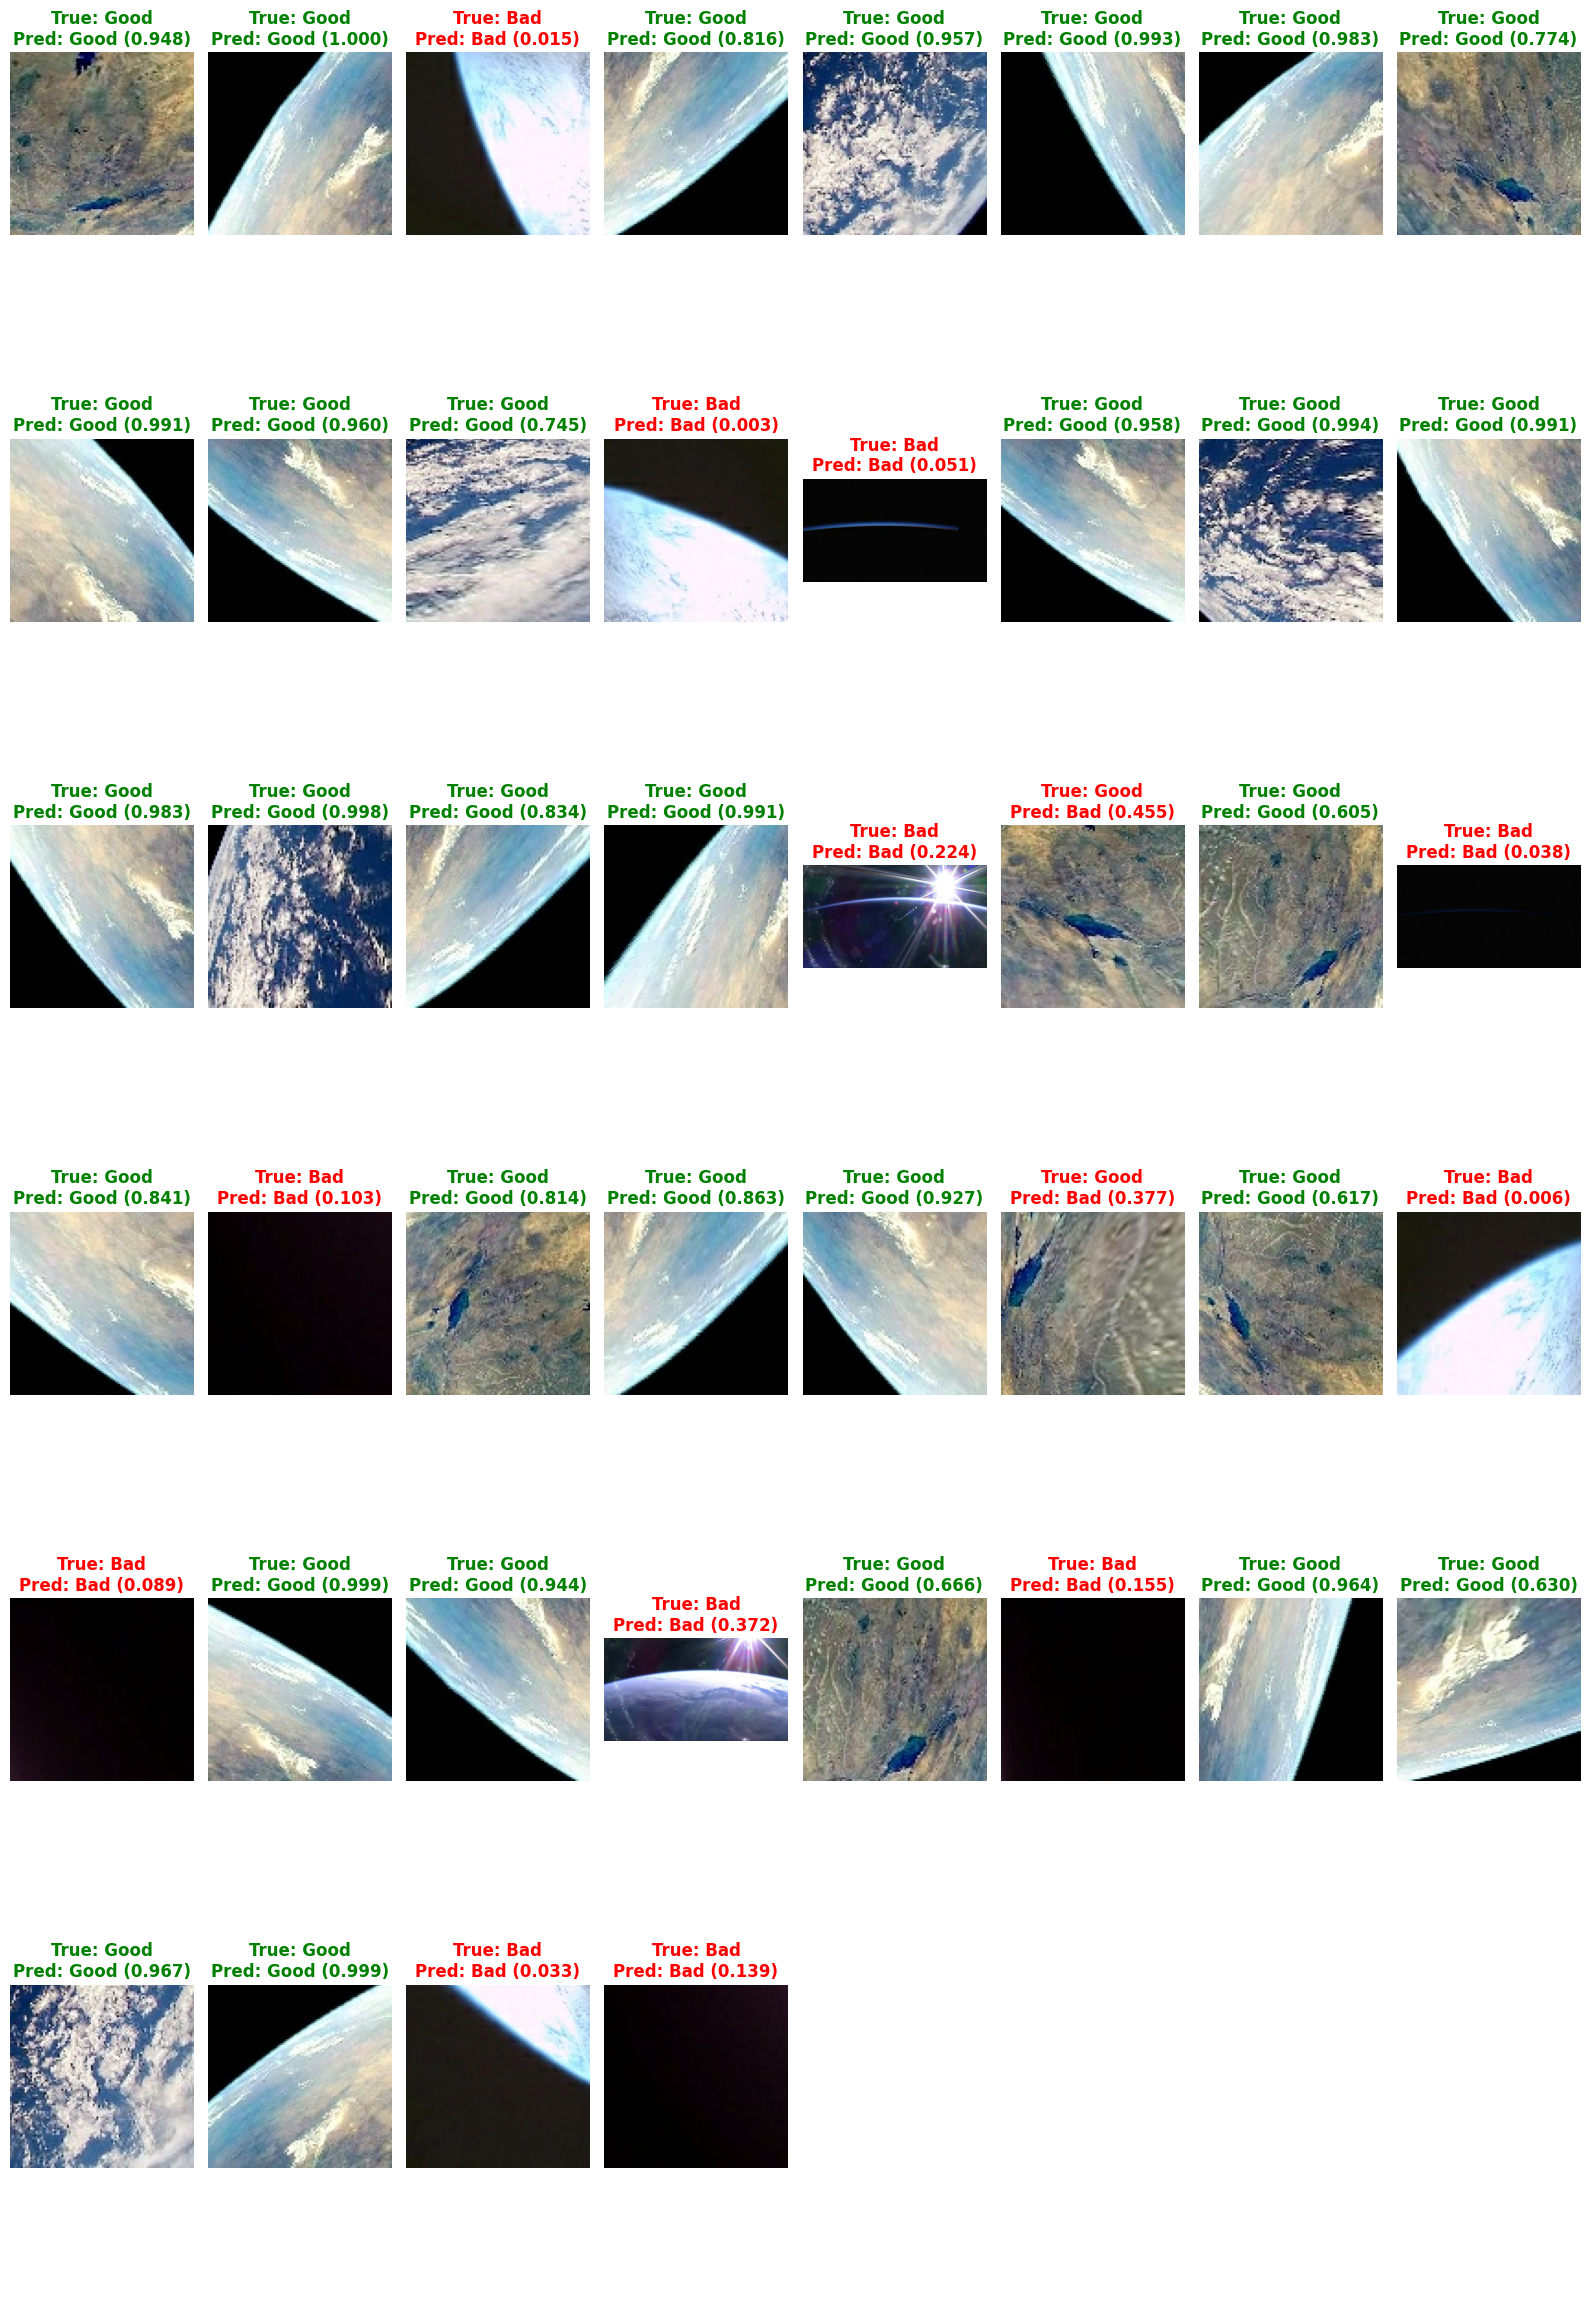

In [ ]:
# Determine grid size
num_images = len(all_test_images)
ncols = 8
nrows = (num_images + ncols - 1) // ncols  # Ceiling division

# Create figure for displaying all test images with predictions
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

# Process each test image
for idx, img_path in enumerate(all_test_images):
    # Load and decode image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_image(img, channels=3)
    
    # Resize and normalize
    resize = tf.image.resize(img, (100, 100))
    input_tensor = tf.expand_dims(resize, 0) / 255.0
    
    # Predict
    yhat = model.predict(input_tensor, verbose=0)
    yhat_value = yhat[0][0]
    
    # Determine predicted class and color
    if yhat_value > 0.5:
        predicted_label = "Good"
        pred_class = 1
        color = "green"
    else:
        predicted_label = "Bad"
        pred_class = 0
        color = "red"
    
    # Determine true label from path - normalize path separators
    normalized_path = img_path.replace('\\', '/')
    if '/good/' in normalized_path:
        true_label = "Good"
        true_class = 1
    elif '/bad/' in normalized_path:
        true_label = "Bad"
        true_class = 0
    else:
        true_label = "Unknown"
        true_class = -1
    
    # Collect for confusion matrix
    if true_class != -1:
        y_true_test.append(true_class)
        y_pred_test.append(pred_class)
    
    # Display image
    axes[idx].imshow(img.numpy())
    axes[idx].set_title(f"True: {true_label}\nPred: {predicted_label} ({yhat_value:.3f})", 
                       color=color, fontweight='bold')
    axes[idx].axis('off')

# Hide extra subplots
for idx in range(num_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

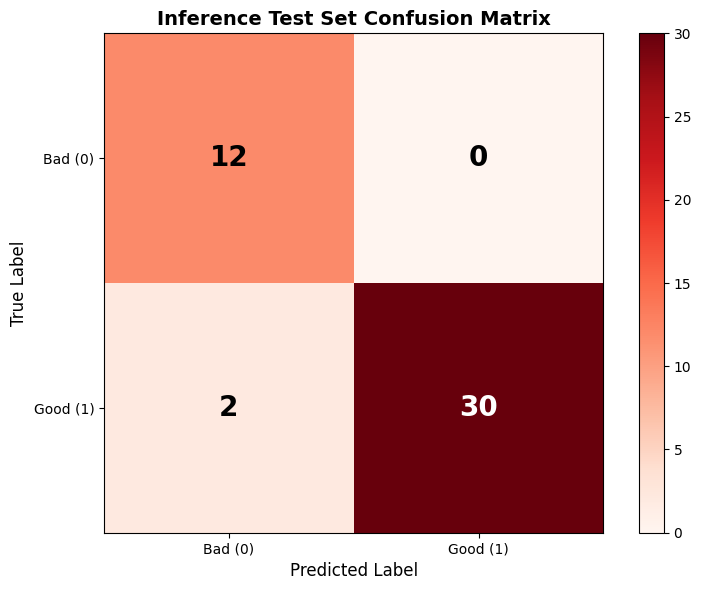

Inference TEST SET - CONFUSION MATRIX ANALYSIS

   ✓ True Negatives (TN):   12 - Correctly predicted as Bad
   ✗ False Positives (FP):   0 - Incorrectly predicted as Good (actually Bad)
   ✗ False Negatives (FN):   2 - Incorrectly predicted as Bad (actually Good)
   ✓ True Positives (TP):   30 - Correctly predicted as Good
   ────────────────────────────────────────────────────────────────────────────
   Total Predictions:       44
   Accuracy:                95.45%
   Precision (TP/TP+FP):   1.0000
   Recall (TP/TP+FN):      0.9375
   F1-Score:               0.9677


In [ ]:
# Calculate Confusion Matrix for External Test Dataset
y_true_external = np.array(y_true_test, dtype=int)
y_pred_external = np.array(y_pred_test, dtype=int)

# Calculate confusion matrix components
tn_external = np.sum((y_true_external == 0) & (y_pred_external == 0))
fp_external = np.sum((y_true_external == 0) & (y_pred_external == 1))
fn_external = np.sum((y_true_external == 1) & (y_pred_external == 0))
tp_external = np.sum((y_true_external == 1) & (y_pred_external == 1))

cm_external = np.array([[tn_external, fp_external], [fn_external, tp_external]])
acc_external = (tn_external + tp_external) / (tn_external + fp_external + fn_external + tp_external) * 100

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm_external, cmap='Reds')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Bad (0)', 'Good (1)'])
ax.set_yticklabels(['Bad (0)', 'Good (1)'])

# Add text annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm_external[i, j], ha="center", va="center", 
               color="white" if cm_external[i, j] > cm_external.max()/2 else "black", 
               fontsize=20, fontweight='bold')

ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Inference Test Set Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print Detailed Metrics
print("=" * 80)
print("Inference TEST SET - CONFUSION MATRIX ANALYSIS")
print("=" * 80)

precision = tp_external / (tp_external + fp_external) if (tp_external + fp_external) > 0 else 0
recall = tp_external / (tp_external + fn_external) if (tp_external + fn_external) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n   ✓ True Negatives (TN):  {tn_external:3d} - Correctly predicted as Bad")
print(f"   ✗ False Positives (FP): {fp_external:3d} - Incorrectly predicted as Good (actually Bad)")
print(f"   ✗ False Negatives (FN): {fn_external:3d} - Incorrectly predicted as Bad (actually Good)")
print(f"   ✓ True Positives (TP):  {tp_external:3d} - Correctly predicted as Good")
print(f"   {'─' * 76}")
print(f"   Total Predictions:      {tn_external + fp_external + fn_external + tp_external:3d}")
print(f"   Accuracy:               {acc_external:6.2f}%")
print(f"   Precision (TP/TP+FP):   {precision:6.4f}")
print(f"   Recall (TP/TP+FN):      {recall:6.4f}")
print(f"   F1-Score:               {f1:6.4f}")
print("=" * 80)

5. Save the model

In [ ]:
flag=False


if flag:
    model.save('../models/20k_dataset/classification_v17_20k(reduced_filter).keras')
    # Saves the trained model to the specified path in HDF5 format